In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import displacement as dpm
from libs import fit_model as fm 

plt.style.use('../libs/my_style.mplstyle')

markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

In [26]:
scale = 0.11
interval = 10

path40_1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241114/MC00MT4uM/beads_tracks.csv"

path43_1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241114/MC03MT4uM/beads_tracks.csv"
path43_2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20251210/MC03MT4uM/beads_tracks.csv"

def get_msd(path):
    track = pd.read_csv(path)
    imsd = dpm.imsd(track, scale, interval, display=bool)
    emsd, _ = dpm.emsd(imsd, display=bool)

    return imsd, emsd

In [27]:
I40_1, MSD40_1 = get_msd(path40_1)
I43_1, MSD43_1 = get_msd(path43_1)
I43_2, MSD43_2 = get_msd(path43_2)

I43_2['particle'] += 10000
IMSD43 = pd.concat([I43_1, I43_2])

/Users/sasakinozomu/code/MTCargo_analysis/libs/displacement.py:164: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  msd_df=pd.concat([msd_df, data])
/Users/sasakinozomu/code/MTCargo_analysis/libs/displacement.py:164: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  msd_df=pd.concat([msd_df, data])
/Users/sasakinozomu/code/MTCargo_analysis/libs/displacement.py:164: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longe

<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_16277/307490660.py:11: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta$ [s]',


[(8.0, 500.0),
 (0.001, 10000.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta$ [s]'),
 Text(0, 0.5, 'MSD $\\langle \\Delta r^2 \\rangle$ $[μm^2]$')]

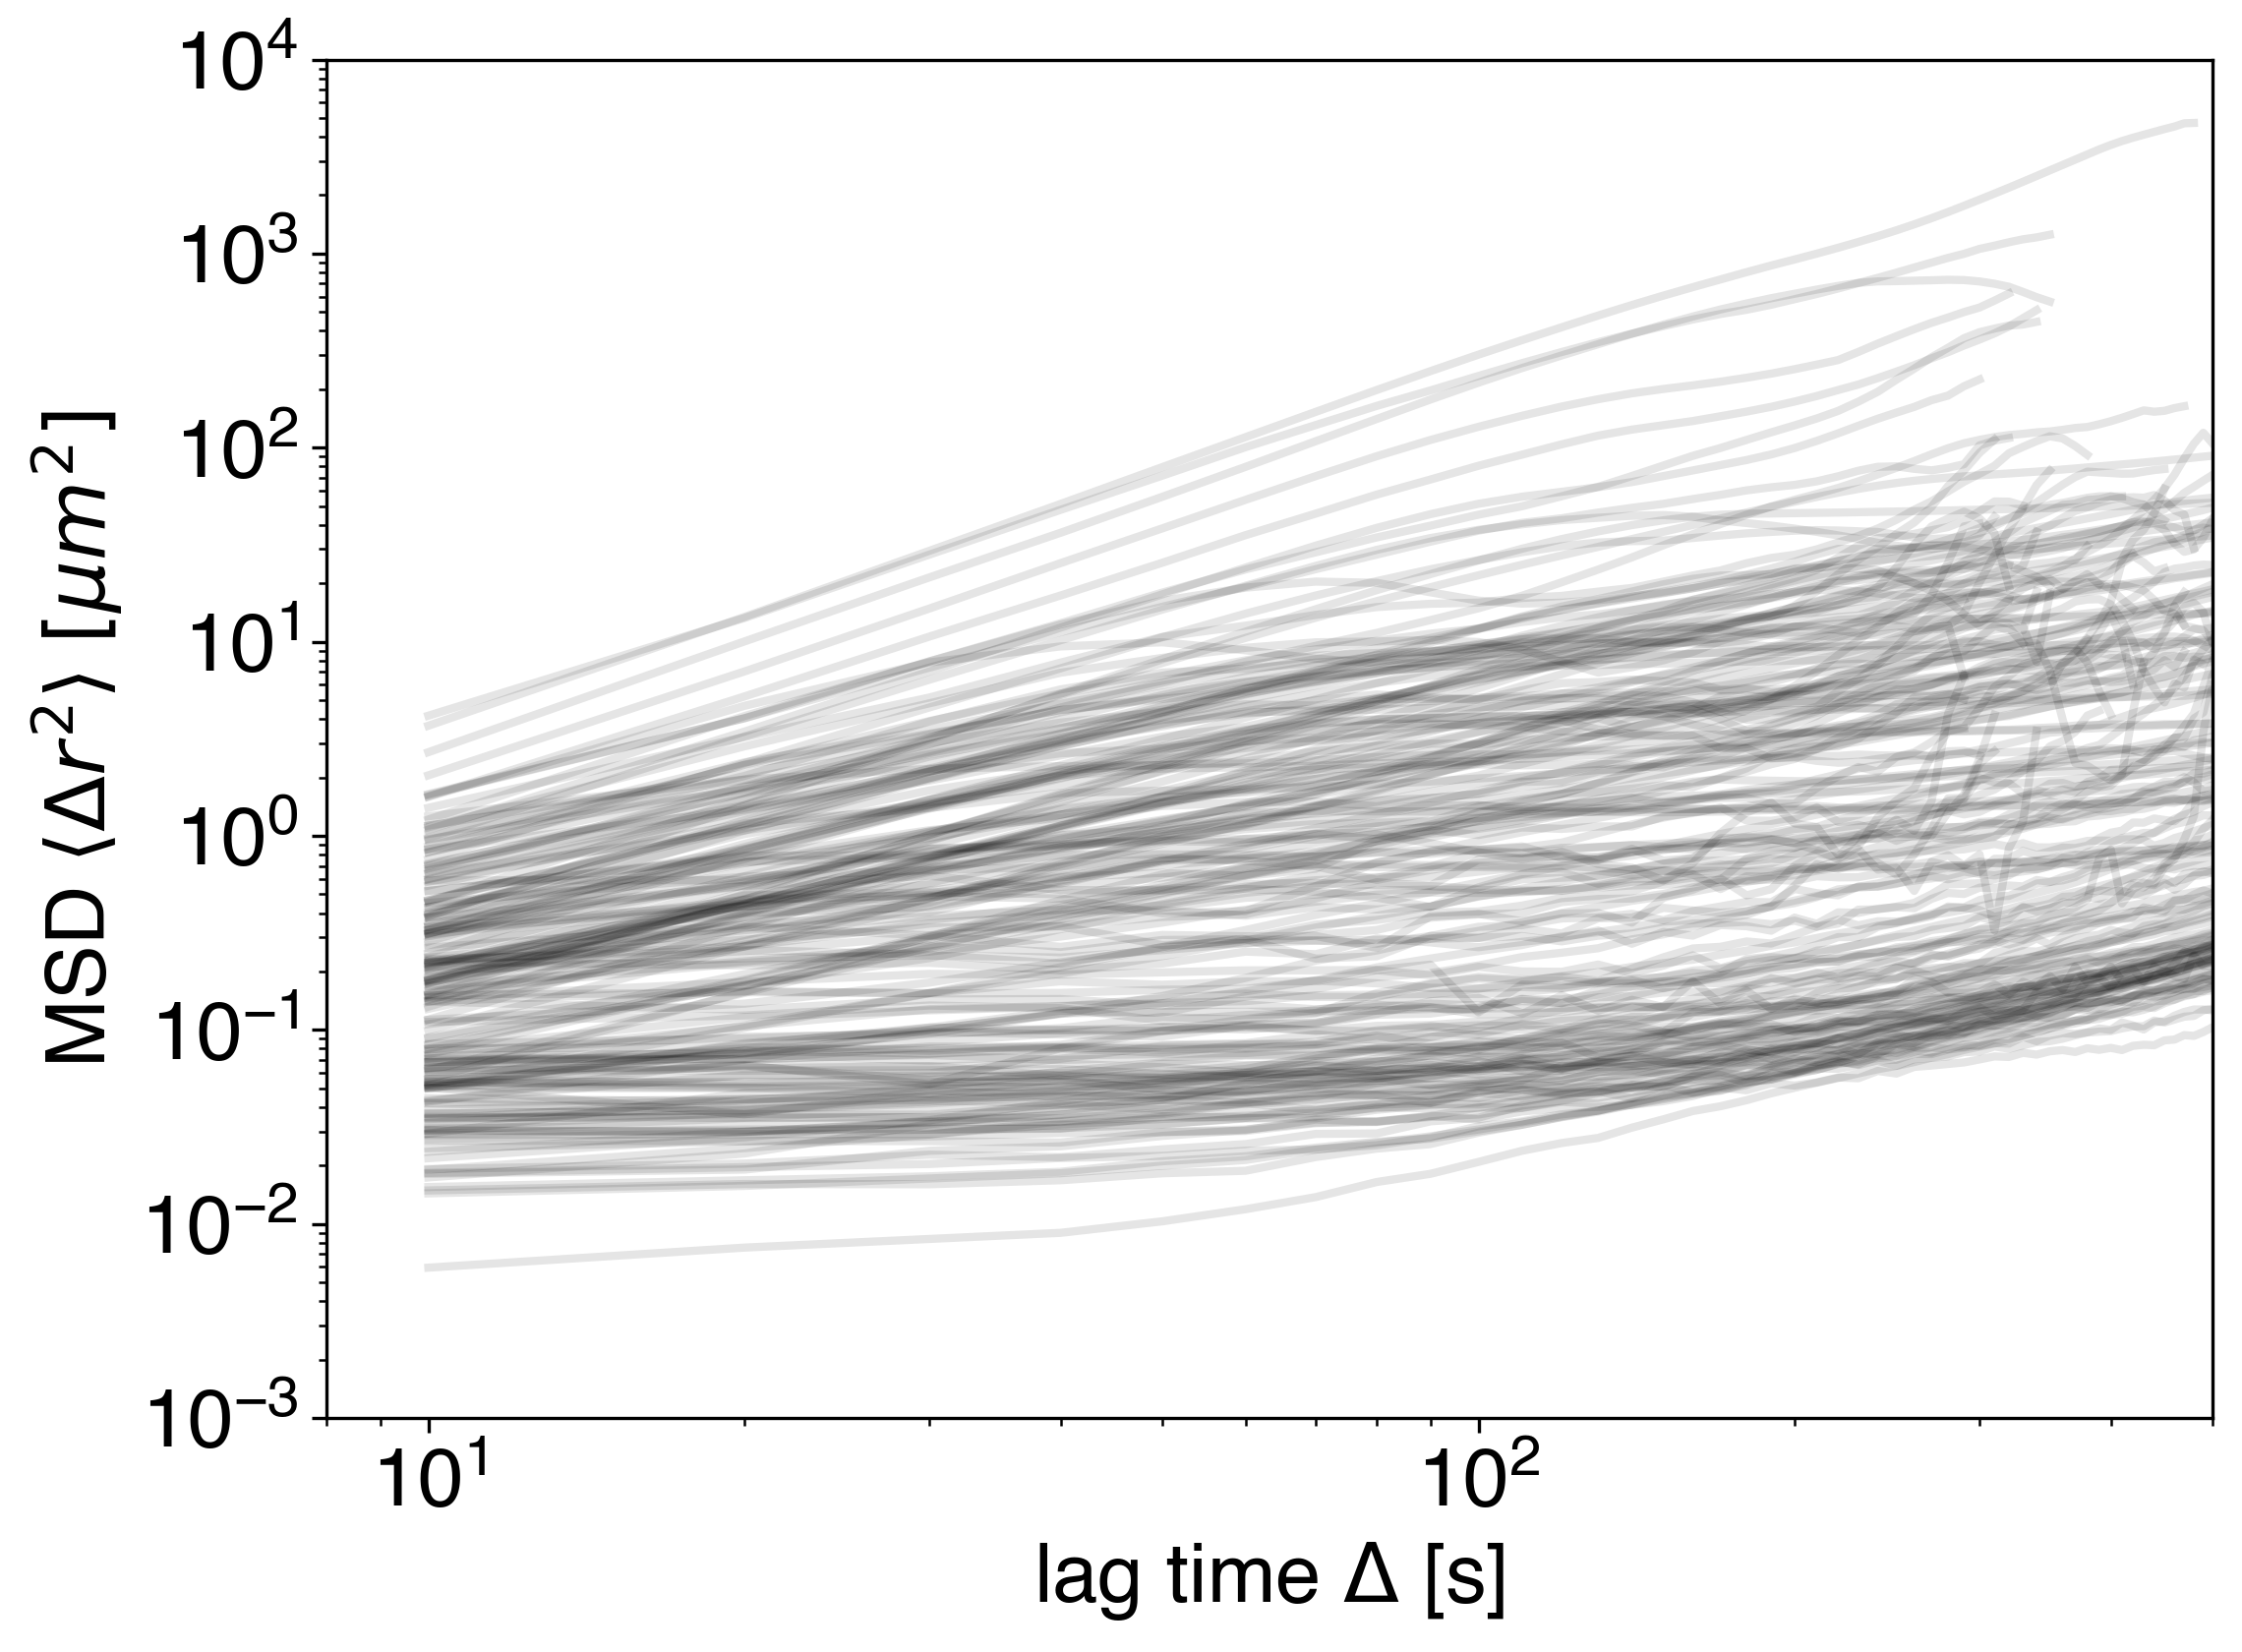

In [28]:
fig, ax = plt.subplots()

for _, p in IMSD43.groupby('particle'):
    ax.plot(p['lag time'], p['MSD'], color = 'black', alpha = 0.1)

ax.set(
    xlim=(0.8*1e1, 5*1e2),
    ylim=(1e-3, 1e4),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ $[\u03bcm^2]$'
    )

<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_16277/1203728064.py:19: SyntaxWarning: invalid escape sequence '\p'
  ax.text(70, 5e1, '$\propto \Delta ^{2.0}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_16277/1203728064.py:20: SyntaxWarning: invalid escape sequence '\p'
  ax.text(120, 0.4*1e1, '$\propto \Delta ^{1.0}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_16277/1203728064.py:39: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta$ [s]',


[(8.0, 500.0),
 (0.1, 100.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta$ [s]'),
 Text(0, 0.5, 'MSD $\\langle \\Delta r^2 \\rangle$ $[μm^2]$')]

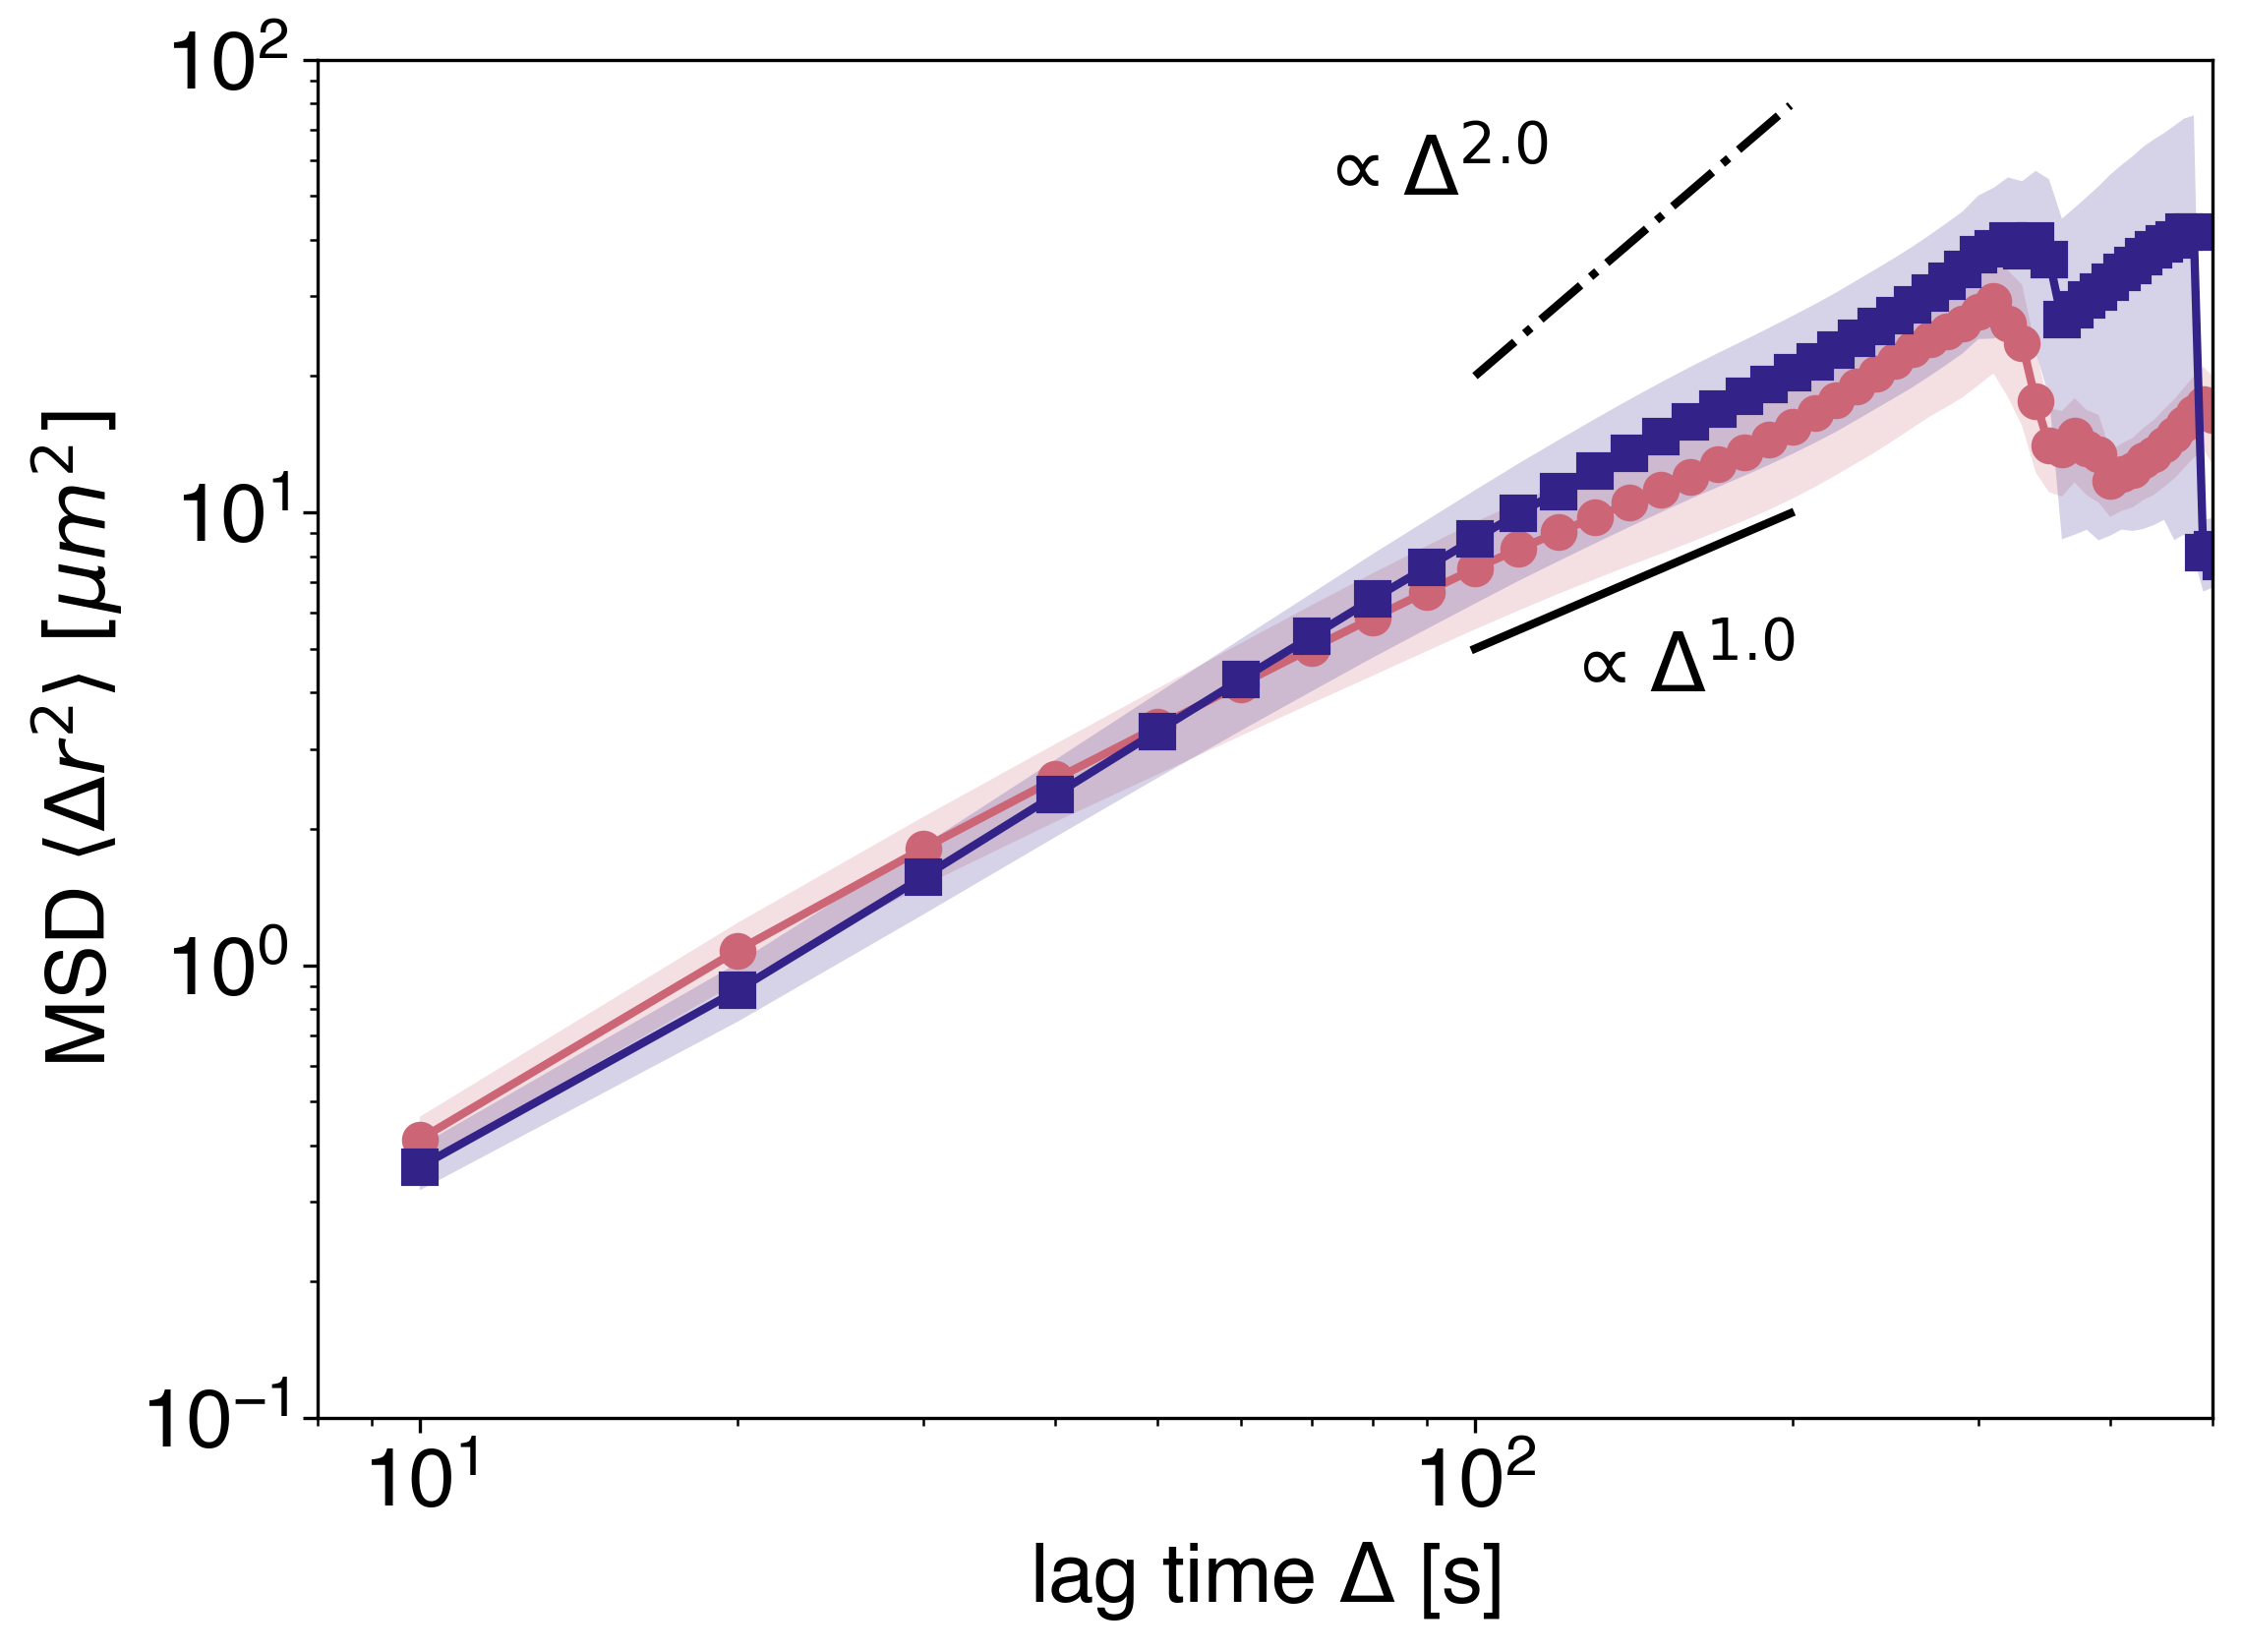

In [29]:
def get_emsd_err(IMSD):
    emsd = IMSD.groupby("lag time").mean()
    emsd_err = IMSD.groupby("lag time").sem()['MSD'].to_numpy()

    return emsd, emsd_err

emsd40, emsd_err40 = get_emsd_err(I40_1)
emsd43, emsd_err43 = get_emsd_err(IMSD43)

fig, ax = plt.subplots()
ty = np.arange(100, 200)

y2 = 2.0e-3 * ty ** 2.0
y3 = 0.05 * ty ** 1.0

ax.plot(ty, y2, c = 'black', linestyle = '-.')
ax.plot(ty, y3, c = 'black', linestyle = '-')

ax.text(70, 5e1, '$\propto \Delta ^{2.0}$')
ax.text(120, 0.4*1e1, '$\propto \Delta ^{1.0}$')

ax.plot(emsd40.index, emsd40['MSD'], marker=markers[0])
ax.fill_between(emsd40.index,
                emsd40['MSD'] - emsd_err40,
                emsd40['MSD'] + emsd_err40,
                alpha=0.2)

ax.plot(emsd43.index, emsd43['MSD'], marker=markers[1])
ax.fill_between(emsd43.index,
                emsd43['MSD'] - emsd_err43,
                emsd43['MSD'] + emsd_err43,
                alpha=0.2)

ax.set(
    xlim=(0.8*1e1, 5*1e2),
    ylim=(1e-1, 1e2),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ $[\u03bcm^2]$'
    )

In [30]:
def fit(emsd, minimum, maximum):
    # Fit log-log in a specified time window
    mask = (emsd.index > minimum) & (emsd.index < maximum)

    # take log10 of selected x and y values and convert to numpy arrays
    x = np.log10(emsd.index[mask].to_numpy())
    y = np.log10(emsd['MSD'][mask].to_numpy())

    # remove non-finite entries (e.g., log of non-positive values)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    # fit
    popt, pcov = curve_fit(fm.ln_pl, x, y, p0=[1.0, 1.0])

    return popt, pcov

minimum = 30
maximum = 250

popt40, pcov40 = fit(emsd40, minimum, maximum)
popt43, pcov43 = fit(emsd43, minimum, maximum)

print(f"40:{popt40[0]}")
print(f"43:{popt43[0]}")

40:1.1076663300429042
43:1.3067712703363032


/Users/sasakinozomu/code/MTCargo_analysis/libs/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)
